C:\Users\Kashish\AppData\Local\Temp\ipykernel_30168\3379283844.py:323: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(


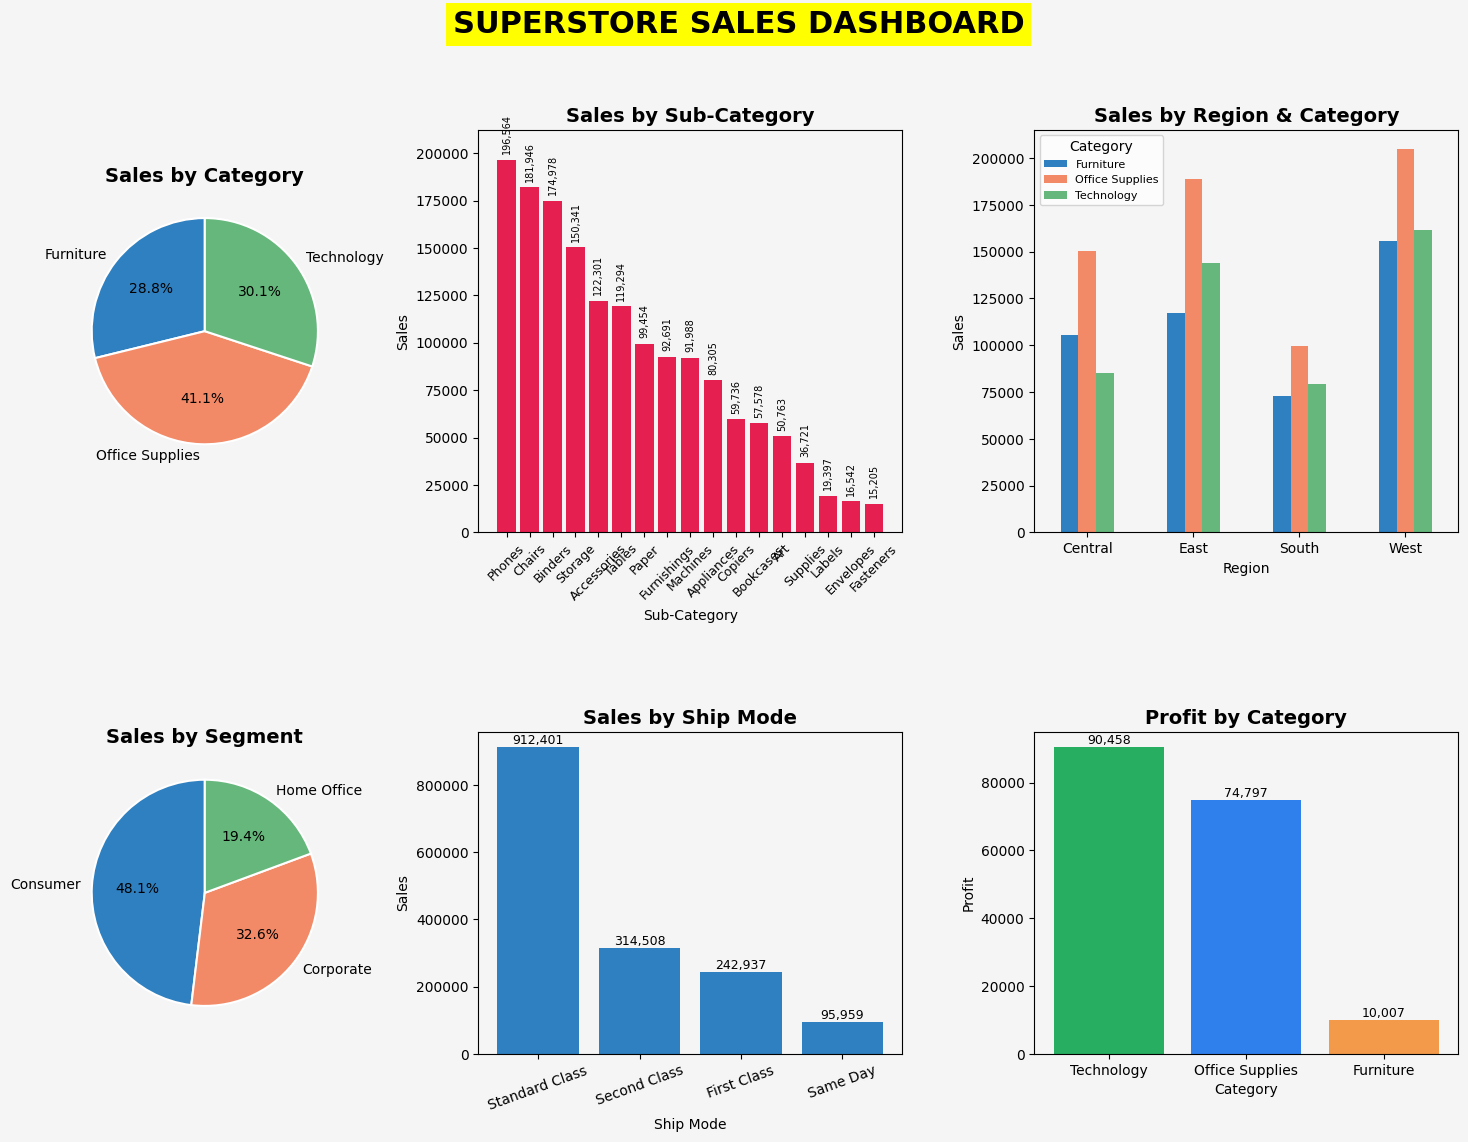

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# COLOR PALETTE
# -----------------------------------

# -----------------------------------
# COLOR PALETTE
# -----------------------------------

BLUE = "#2F80C0"
TEAL = "#62B99F"
ORANGE = "#F28A68"
YELLOW = "#F4D35E"
GREEN = "#65B77B"
RED = "#E51F4F"
LIGHT_BLUE = "#55B9D9"

colors = [
    BLUE,
    TEAL,
    ORANGE,
    YELLOW,
    GREEN,
    RED,
    LIGHT_BLUE
]
# -----------------------------------
# 1. LOAD DATA
# -----------------------------------

df = pd.read_csv("SuperStore_Sales_Dataset.csv")


# -----------------------------------
# 2. CLEAN DATA
# -----------------------------------

df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")

df = df.dropna(subset=["Sales", "Category", "Sub-Category"])


# -----------------------------------
# 3. CREATE DASHBOARD
# -----------------------------------

fig = plt.figure(figsize=(18, 12))

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[1, 1.5, 1.5],
    height_ratios=[1.25, 1],
    hspace=0.55,
    wspace=0.35
)


# -----------------------------------
# 4. TITLE
# -----------------------------------

fig.suptitle(
    "SUPERSTORE SALES DASHBOARD",
    fontsize=22,
    fontweight="bold",
    bbox=dict(
        facecolor="yellow",
        edgecolor="none",
        pad=5
    )
)


# -----------------------------------
# 5. SALES BY CATEGORY
# -----------------------------------

ax1 = fig.add_subplot(gs[0, 0])

category_sales = df.groupby("Category")["Sales"].sum()

ax1.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[BLUE, ORANGE, GREEN],
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)

ax1.set_title(
    "Sales by Category",
    fontsize=14,
    fontweight="bold"
)


# -----------------------------------
# 6. SALES BY SUB-CATEGORY
# -----------------------------------

ax2 = fig.add_subplot(gs[0, 1])

subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

bars = ax2.bar(
    subcategory_sales.index,
    subcategory_sales.values,
    color=RED
)

ax2.set_title(
    "Sales by Sub-Category",
    fontsize=14,
    fontweight="bold"
)

ax2.set_xlabel("Sub-Category")
ax2.set_ylabel("Sales")

ax2.tick_params(
    axis="x",
    rotation=45,
    labelsize=9
)

for bar in bars:

    height = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 3000,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=7,
        rotation=90
    )

ax2.margins(y=0.08)

# -----------------------------------
# 7. SALES BY REGION & CATEGORY
# -----------------------------------

ax3 = fig.add_subplot(gs[0, 2])

region_category = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

region_category.plot(
    kind="bar",
    ax=ax3,
    color=[ BLUE, ORANGE, GREEN]
)

ax3.set_title(
    "Sales by Region & Category",
    fontsize=14,
    fontweight="bold"
)

ax3.set_xlabel("Region")
ax3.set_ylabel("Sales")

ax3.tick_params(
    axis="x",
    rotation=0
)

ax3.legend(
    title="Category",
    fontsize=8
)


# -----------------------------------
# 8. SALES BY SEGMENT
# -----------------------------------

ax4 = fig.add_subplot(gs[1, 0])

segment_sales = df.groupby("Segment")["Sales"].sum()

ax4.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[BLUE, ORANGE, GREEN],
    wedgeprops={"edgecolor": "white",
    "linewidth": 1.5}
)

ax4.set_title(
    "Sales by Segment",
    fontsize=14,
    fontweight="bold"
)


# -----------------------------------
# 9. SALES BY SHIP MODE
# -----------------------------------

ax5 = fig.add_subplot(gs[1, 1])

ship_sales = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

bars = ax5.bar(
    ship_sales.index,
    ship_sales.values,
    color=BLUE
)

ax5.set_title(
    "Sales by Ship Mode",
    fontsize=14,
    fontweight="bold"
)

ax5.set_xlabel("Ship Mode")
ax5.set_ylabel("Sales")

ax5.tick_params(
    axis="x",
    rotation=20
)

for bar in bars:

    height = bar.get_height()

    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# -----------------------------------
# 10. PROFIT BY CATEGORY
# -----------------------------------

ax6 = fig.add_subplot(gs[1, 2])

profit_category = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

category_colors = {
    "Furniture": "#F2994A",
    "Office Supplies": "#2F80ED",
    "Technology": "#27AE60"
}

bars = ax6.bar(
    profit_category.index,
    profit_category.values,
    color=[
        category_colors.get(category, "#2F80ED")
        for category in profit_category.index
    ]
)

ax6.set_title(
    "Profit by Category",
    fontsize=14,
    fontweight="bold"
)

ax6.set_xlabel("Category")
ax6.set_ylabel("Profit")

ax6.tick_params(
    axis="x",
    rotation=0
)

for bar in bars:

    height = bar.get_height()

    ax6.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
    ax.set_facecolor("#F5F5F5")

fig.patch.set_facecolor("#F5F5F5")

plt.tight_layout(
    rect=[0,0,1,0.93],
    pad=2
)